<a href="https://colab.research.google.com/github/CodesTree/UndergradBeginnerProjects/blob/main/SWA_Individual_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Individual Analysis: Chan Zheng Shao (24020059)

Dataset Used: https://archive.ics.uci.edu/dataset/438/health+news+in+twitter

Goal: Topic Modelling for health news on Twitter

In [ ]:
#Importing libraries and setting up dataset to be loaded as DataFrame
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reference: https://stackoverflow.com/questions/51536708/python-catch-exception-pandas-errors-parsererror-error-tokenizing-data-c-erro

In [ ]:
#Define folder path
folder_path = '/content/drive/My Drive/SWA/Final Assignment Individual/health+news+in+twitter/Health-Tweets'

#List files in the directory
files = os.listdir(folder_path)
print(files)

#Read each text file into a DataFrame
dataframes = []
for file in files:
  #Try-except block was created to solve the issue of some rows in the files having a '|' within it that wasn't a separator
  try:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path, header=None, names=['tweetID', 'datetime', 'tweet'], delimiter='|',encoding='latin1')
    dataframes.append(df)
    print(f"Done reading {file}")
  #When a '|' that exceeds the columns created is found throw error
  except pd.errors.ParserError as e:
    print(f"Error reading {file}: {e}")

#Combining all files into a single DataFrame
df_combined = pd.concat(dataframes, ignore_index=True)

['goodhealth.txt', 'everydayhealth.txt', 'nprhealth.txt', 'nytimeshealth.txt', 'foxnewshealth.txt', 'cnnhealth.txt', 'KaiserHealthNews.txt', 'wsjhealth.txt', 'reuters_health.txt', 'cbchealth.txt', 'usnewshealth.txt', 'msnhealthnews.txt', 'gdnhealthcare.txt', 'NBChealth.txt', 'latimeshealth.txt', 'bbchealth.txt']
Error reading goodhealth.txt: Error tokenizing data. C error: Expected 3 fields in line 4015, saw 4

Done reading everydayhealth.txt
Done reading nprhealth.txt
Error reading nytimeshealth.txt: Error tokenizing data. C error: Expected 3 fields in line 71, saw 4

Done reading foxnewshealth.txt
Error reading cnnhealth.txt: Error tokenizing data. C error: Expected 3 fields in line 1422, saw 4

Error reading KaiserHealthNews.txt: Error tokenizing data. C error: Expected 3 fields in line 523, saw 4

Done reading wsjhealth.txt
Done reading reuters_health.txt
Error reading cbchealth.txt: Error tokenizing data. C error: Expected 3 fields in line 846, saw 4

Done reading usnewshealth.txt

In [ ]:
df_combined.sample(5)

,tweetID,datetime,tweet
22259,116940924885532673,Thu Sep 22 18:24:23 +0000 2011,New Report Casts More Doubt on Virus' Link to ...
24974,394112475492515840,Sat Oct 26 14:45:11 +0000 2013,Tweeting bra exposed: Genuine support or publi...
29310,323058130718171138,Sat Apr 13 13:00:35 +0000 2013,Yoga has more to offer than traditional classe...
832,301043095108194304,Mon Feb 11 19:00:41 +0000 2013,We're joined today by #vegan experts and autho...
8578,575305174241132545,Tue Mar 10 14:40:16 +0000 2015,Got diabetes? Theres an app for that http://...


In [ ]:
#Checking for null/Nan values
df_combined.isnull().sum()

,0
tweetID,0
datetime,0
tweet,0


In [ ]:
#Checking for duplicates
df_combined.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
34899,False
34900,False
34901,False
34902,False


In [ ]:
#Detailed showing of duplicates
duplicate = df_combined[df_combined.duplicated(keep='last')] #Storing duplicates in a new df to identify duplicates

print(f"Duplicate Rows : {duplicate}")

Duplicate Rows : Empty DataFrame
Columns: [tweetID, datetime, tweet]
Index: []


Data Preprocessing

References:


1.   https://www.kaggle.com/code/canggih/topic-modeling
2.   https://www.kaggle.com/code/rcushen/topic-modelling-with-lsa-and-lda#Exploratory-Data-Analysis



Step 1:Keeping relevant columns

In [ ]:
df_transform = df_combined.copy()

In [ ]:
df_transform.drop('tweetID', axis=1, inplace= True)

In [ ]:
df_transform.sample(5)

,datetime,tweet
28541,Wed Aug 07 20:27:37 +0000 2013,"WHOA! MRT @MyLastBite After 7 months of 10,000..."
6130,Fri Oct 25 04:14:35 +0000 2013,"A Diagram Of http://HealthCare.gov, Based On T..."
4230,Sun Aug 17 13:46:40 +0000 2014,Kenya Shuts Borders To Ebola-Hit West African ...
20361,Mon Mar 26 16:46:34 +0000 2012,Teen Girl Drivers Likelier to Use Electronic D...
6071,Thu Oct 31 08:56:56 +0000 2013,Add Security To The List Of http://HealthCare....


Step 2: Cleaning datetime into day, month, date, time, year

In [ ]:
#Convert datetime column to datetime object
df_transform['datetime'] = pd.to_datetime(df_transform['datetime'], format='%a %b %d %H:%M:%S %z %Y')

#Extract relevant components into date, day_of_week, month, hour, and year
df_transform['date'] = df_transform['datetime'].dt.date
df_transform['day_of_week'] = df_transform['datetime'].dt.day_name()
df_transform['month'] = df_transform['datetime'].dt.month_name()
df_transform['hour'] = df_transform['datetime'].dt.hour
df_transform['year'] = df_transform['datetime'].dt.year
df_transform['year'] = df_transform['year'].astype(int) #Converting into integer to be used in visualizing topics by year

In [ ]:
df_transform.sample(5)

,datetime,tweet,date,day_of_week,month,hour,year
11191,2014-09-08 13:22:34+00:00,RT @stefaniei: Carmat implants its artificial ...,2014-09-08,Monday,September,13,2014
27981,2014-02-20 19:18:36+00:00,RT @hiltzikm: The anti-vaccination movement br...,2014-02-20,Thursday,February,19,2014
10775,2014-10-14 16:26:52+00:00,RT @janetadamy: Can dogs spread Ebola? http://...,2014-10-14,Tuesday,October,16,2014
29243,2013-05-20 16:29:04+00:00,"When the healthcare law takes full effect, com...",2013-05-20,Monday,May,16,2013
9398,2015-01-15 20:20:24+00:00,Abuse of opiate-based #painkillers may be on d...,2015-01-15,Thursday,January,20,2015


In [ ]:
#Removing datetime to clean DataFrame
df_transform.drop('datetime', axis=1, inplace=True)

In [ ]:
#Reordering DataFrame
df_transform = df_transform [['date', 'day_of_week', 'month', 'hour', 'year', 'tweet']]

In [ ]:
df_transform.sample(5)

,date,day_of_week,month,hour,year,tweet
10329,2014-11-25,Tuesday,November,14,2014,RT @TomBurtonWSJ: Novartis dismisses employee ...
33504,2014-04-11,Friday,April,1,2014,Longer waits but NHS holds its own http://bbc....
33043,2014-06-19,Thursday,June,1,2014,Suicide alert 'may have backfired' http://bbc....
27997,2014-02-14,Friday,February,18,2014,"Birds do it. Bees do it. Sharks, spiders and p..."
24542,2014-01-27,Monday,January,0,2014,Royal Caribbean cruise to end early; more than...


Step 3: Preprocessing 'tweet' column

In [ ]:
#Importing regex library to help remove URL from tweet
import re

#Importing libraries to tokenize and remove stopwords
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

#Importing library to lemmatize tweets
from nltk.stem.wordnet import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
#Initialize stopwords in english
stop_words = set(stopwords.words('english'))

#Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

In [ ]:
#Making a function to remove URL and tokenize the tweets for each row in the DataFrame
def preprocess_tweet(tweet):
    tweet = re.sub(r'http\S+', '', tweet)
    tokens = word_tokenize(tweet.lower())
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(tokens)

df_transform['cleaned_tweet'] = df_transform['tweet'].apply(preprocess_tweet)

In [ ]:
df_transform.sample(5)

,date,day_of_week,month,hour,year,tweet,cleaned_tweet
18063,2015-04-02,Thursday,April,21,2015,Think giving your kids a sip of #wine or #beer...,think giving kid sip wine beer give healthy at...
15849,2014-10-24,Friday,October,12,2014,EU backs drug for rare sun intolerance from Au...,eu back drug rare sun intolerance australia cl...
31788,2014-12-10,Wednesday,December,5,2014,VIDEO: WHO: 'Ebola running ahead of us' http:/...,video running ahead u
7945,2012-10-12,Friday,October,8,2012,Patients Worry Meningitis Symptoms Could Be Do...,patient worry meningitis symptom could dormant...
20666,2012-02-27,Monday,February,23,2012,Rapid Flu Tests a Good First Step: Study: htt...,rapid flu test good first step study


Building LDA Model

In [ ]:
#Importing libraries for topic modelling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as lda

#Importing numpy library
import numpy as np

In [ ]:
#Initialize vectorizer
vectorizer = CountVectorizer()

In [ ]:
#Create and fit the vectorizer
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df_transform['cleaned_tweet'])

#Create and fit the LDA model
num_topics = 5
model = lda(n_components=num_topics, random_state=42)
model.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
print(type(model))

<class 'sklearn.decomposition._lda.LatentDirichletAllocation'>


In [ ]:
#Function to get top n words
def get_top_n_words(n, lda_model, vectorizer):
    feature_names = vectorizer.get_feature_names_out()
    top_words = {}

    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = np.argsort(topic)[::-1][:n]
        top_words[topic_idx] = [feature_names[i] for i in top_indices]

    return top_words

#Assuming lda is the fitted LDA model and vectorizer is fitted as well
top_n = 3
top_words = get_top_n_words(top_n, model, vectorizer)

#Print the top words for each topic
for topic, words in top_words.items():
    print(f"Topic {topic}: {' '.join(words)}")

Topic 0: rt patient hospital
Topic 1: cancer study drug
Topic 2: health care new
Topic 3: ebola study risk
Topic 4: healthtalk rt food


In [ ]:
#Importing plots and graphs libraries
import matplotlib.pyplot as plt

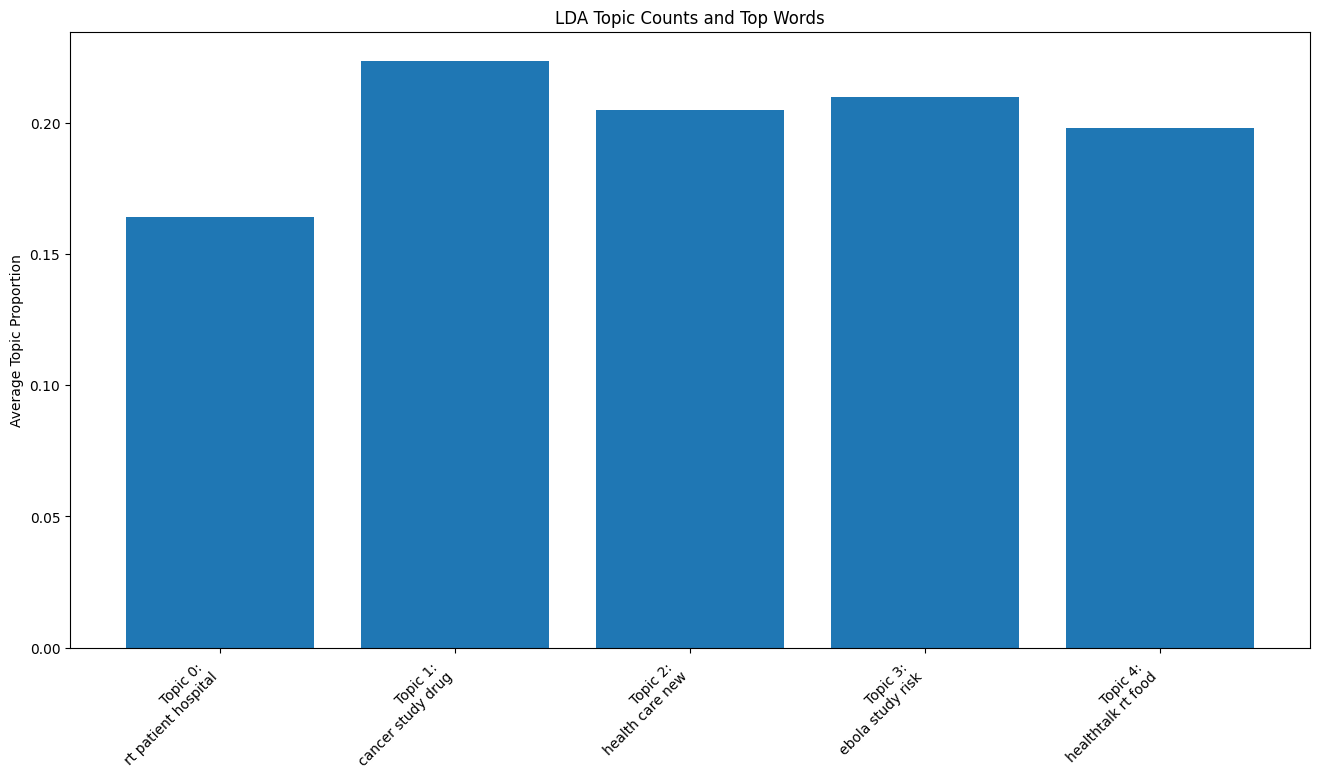

In [ ]:
#Prepare labels for plotting
labels = ['Topic {}: \n{}'.format(i, ' '.join(top_words[i])) for i in range(len(top_words))]

#Count of topics (for visualization)
doc_topic_dist = model.transform(dtm)
topic_counts = np.mean(doc_topic_dist, axis=0) # Average topic distribution

#Plot the results
fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(range(len(top_words)), topic_counts)
ax.set_xticks(range(len(top_words)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Average Topic Proportion')
ax.set_title('LDA Topic Counts and Top Words')
plt.show()

In [ ]:
#Create a dictionary to hold dataframes for each year
dataframes_by_year = {year: df_transform[df_transform['year'] == year] for year in df_transform['year'].unique()}

In [ ]:
dataframes_by_year

{2013:              date day_of_week      month  hour  year  \
 0      2013-02-21    Thursday   February    14  2013   
 1      2013-02-21    Thursday   February    14  2013   
 2      2013-02-21    Thursday   February    13  2013   
 3      2013-02-21    Thursday   February    13  2013   
 4      2013-02-21    Thursday   February    12  2013   
 ...           ...         ...        ...   ...   ...   
 34899  2013-09-30      Monday  September    19  2013   
 34900  2013-09-30      Monday  September    15  2013   
 34901  2013-09-30      Monday  September    13  2013   
 34902  2013-09-30      Monday  September    13  2013   
 34903  2013-09-30      Monday  September     6  2013   
 
                                                    tweet  \
 0      #FastFood Makes Up 11 Percent of #Calories in ...   
 1      10 snacks to help you lose weight, burn fat, a...   
 2      10 foods that boost your skin AND slim your wa...   
 3      What a heart attack feels like in women (it's ...   
 4 

In [ ]:
#Function to perform LDA for each year
def perform_lda(df, num_topics):
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    dtm = vectorizer.fit_transform(df['cleaned_tweet'])
    lda_model = lda(n_components=num_topics, random_state=42)
    lda_model.fit(dtm)
    return lda_model, vectorizer, dtm

In [ ]:
#Perform LDA for each year and store results in dictionary to be accessed as year:data
lda_models = {}
vectorizers = {}
dtms = {}

for year, df in dataframes_by_year.items():
    lda_model, vectorizer, dtm = perform_lda(df, num_topics)
    lda_models[year] = lda_model
    vectorizers[year] = vectorizer
    dtms[year] = dtm

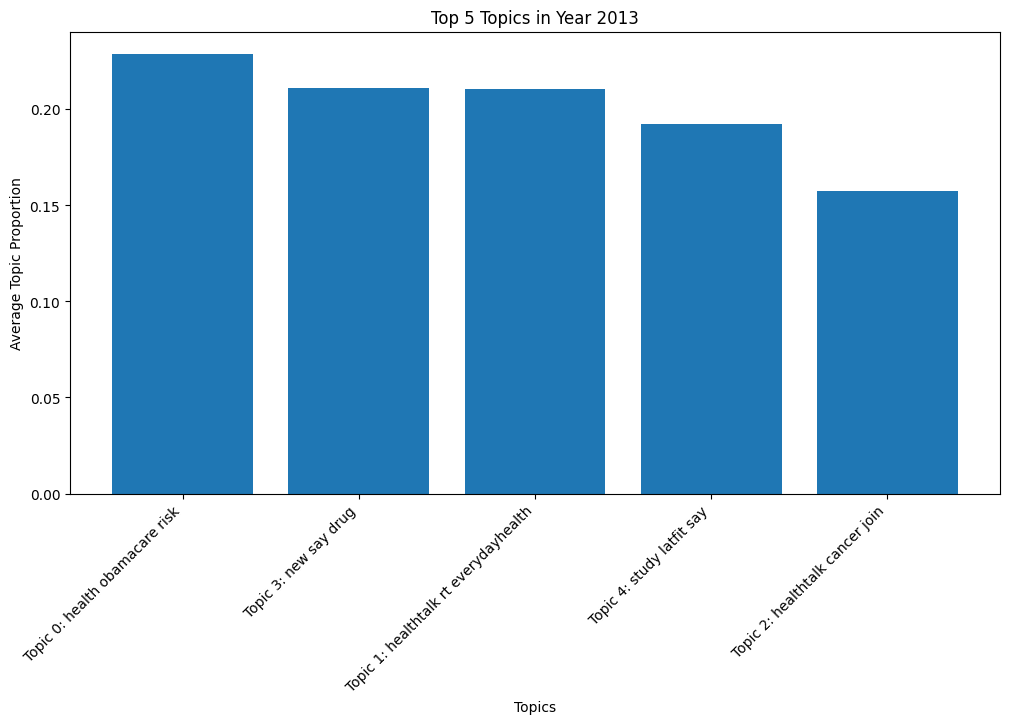

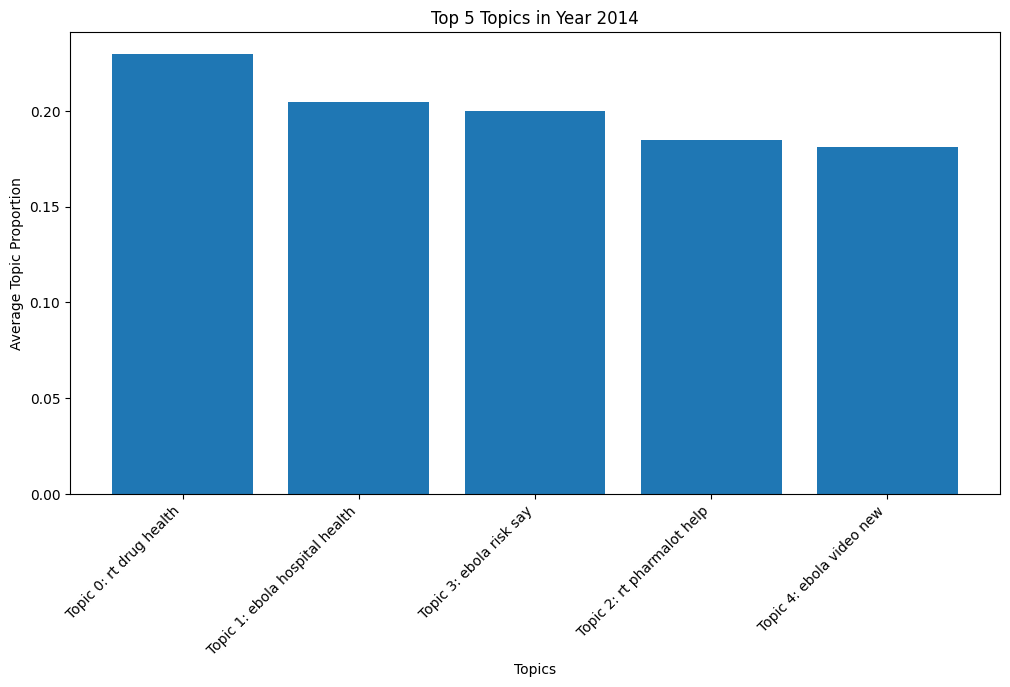

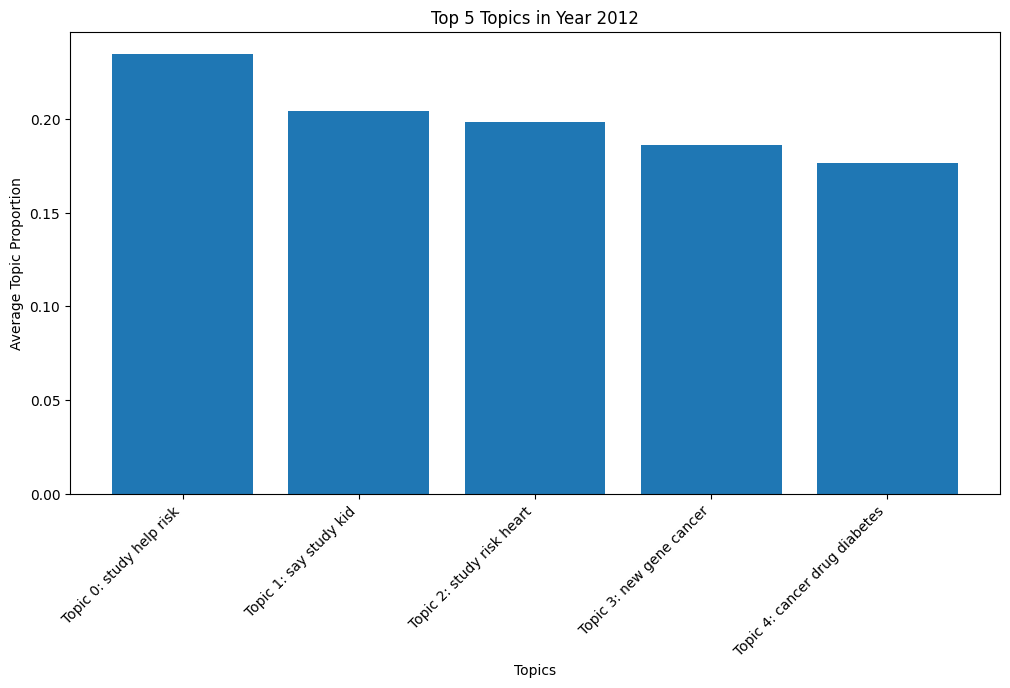

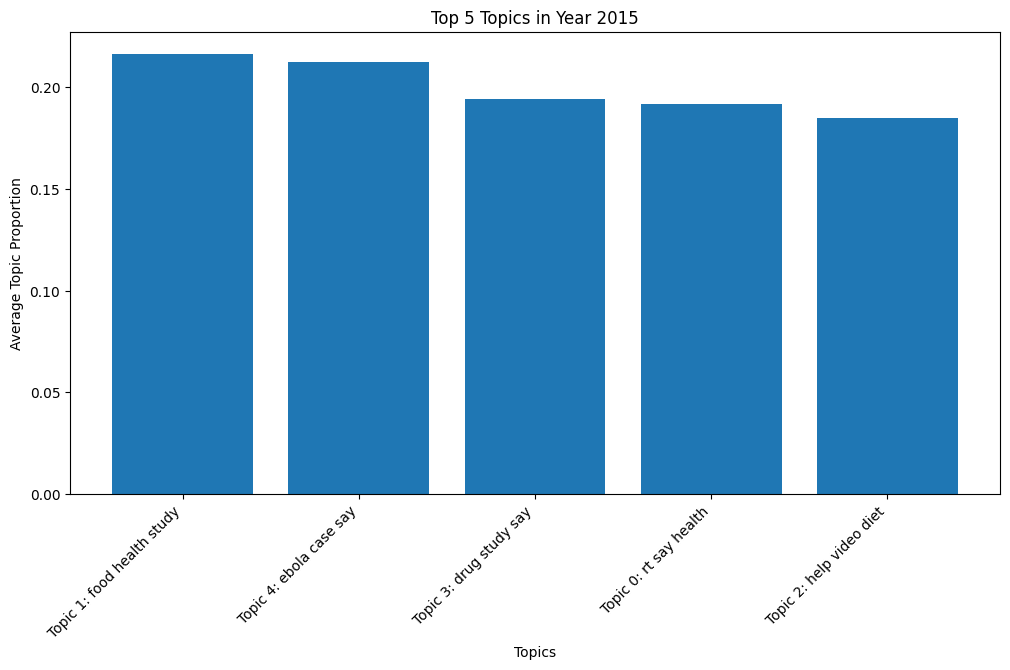

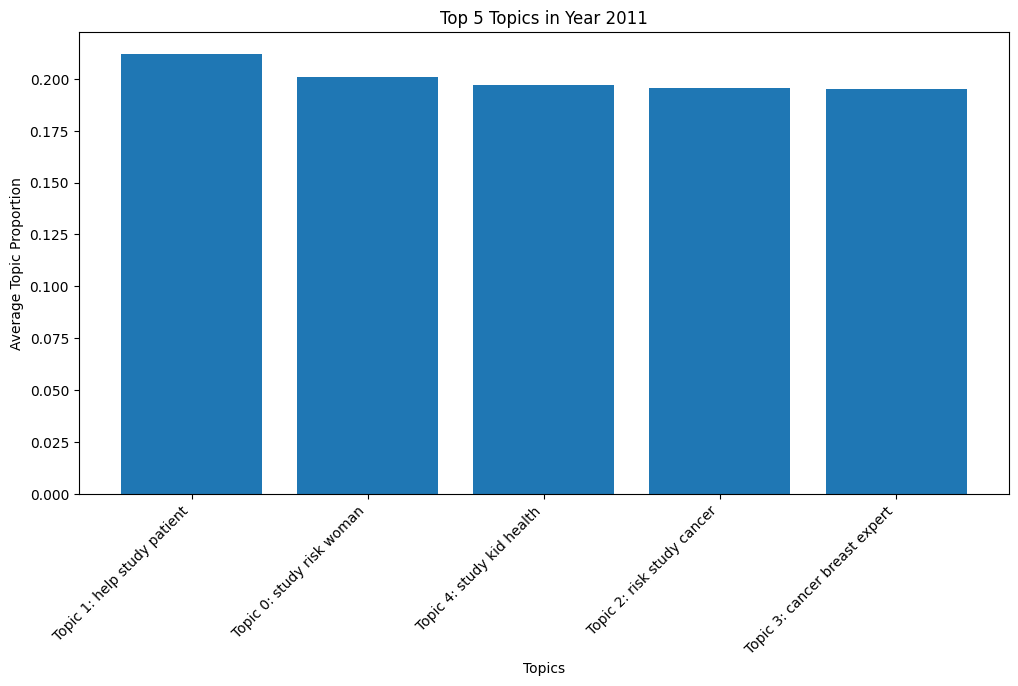

In [ ]:
#Plot the top topics for each year
for year, lda_model in lda_models.items():
    vectorizer_year = vectorizers[year]
    dtm_year = dtms[year]

    #Get top words for the current year's LDA model
    top_words = get_top_n_words(top_n, lda_model, vectorizer_year)

    #Get the document-topic distribution
    doc_topic_dist_year = lda_model.transform(dtm_year)

    #Aggregate topic distributions across documents
    topic_proportions = np.mean(doc_topic_dist_year, axis=0)

    #Get the top 5 topics
    top_topics = topic_proportions.argsort()[::-1][:5]
    top_topics_values = topic_proportions[top_topics]

    #Prepare labels for the top 5 topics
    labels = ['Topic {}: {}'.format(i, ' '.join(top_words[i])) for i in top_topics]

    #Plot the top 5 topics
    plt.figure(figsize=(12, 6))
    plt.bar(range(5), top_topics_values, tick_label=labels)
    plt.xlabel('Topics')
    plt.ylabel('Average Topic Proportion')
    plt.title(f'Top 5 Topics in Year {year}')
    plt.xticks(rotation=45, ha='right')
    plt.show()